In [1]:
from pathlib import Path
import sys
import random

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import (
    load_text_file,
    clean_dataset,
)

from src.tokenizer import (
    ArabicCharacterTokenizer,
)

from src.ngram import (
    CharacterNGramModel,
)

from src.evaluation import (
    evaluate_model,
    calculate_unknown_context_rate,
)

In [2]:
dataset_path = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "arabic_sample.txt"
)

dataset = load_text_file(
    dataset_path
)

dataset = clean_dataset(
    dataset
)

print(
    f"Number of samples: {len(dataset)}"
)

Number of samples: 12


In [5]:
random.seed(42)

shuffled_dataset = list(dataset)

random.shuffle(
    shuffled_dataset
)

test_size = 0.20

test_count = max(
    1,
    int(len(shuffled_dataset) * test_size)
)

test_dataset = shuffled_dataset[
    :test_count
]

train_dataset = shuffled_dataset[
    test_count:
]

print(
    f"Training samples: {len(train_dataset)}"
)

print(
    f"Testing samples: {len(test_dataset)}"
)

Training samples: 10
Testing samples: 2


In [6]:
tokenizer = (
    ArabicCharacterTokenizer()
)

tokenizer.fit(
    train_dataset
)

print(
    f"Vocabulary size: "
    f"{tokenizer.vocabulary_size}"
)

Vocabulary size: 34


In [7]:
models = {}

for n in [2, 3, 4]:

    model = CharacterNGramModel(
        n=n
    )

    model.fit(
        train_dataset,
        tokenizer,
    )

    models[n] = model

    print(
        f"{n}-gram trained."
    )

2-gram trained.
3-gram trained.
4-gram trained.


In [8]:
results = []

for n, model in models.items():

    metrics = evaluate_model(
        model,
        test_dataset,
        tokenizer,
    )

    unknown_rate = (
        calculate_unknown_context_rate(
            model,
            test_dataset,
            tokenizer,
        )
    )

    result = {
        "model": f"{n}-gram",
        "cross_entropy": metrics[
            "cross_entropy"
        ],
        "perplexity": metrics[
            "perplexity"
        ],
        "unknown_context_rate": unknown_rate,
    }

    results.append(
        result
    )

results

[{'model': '2-gram',
  'cross_entropy': 3.4599964757118826,
  'perplexity': 11.004307663208046,
  'unknown_context_rate': 0.0},
 {'model': '3-gram',
  'cross_entropy': 2.953452849351723,
  'perplexity': 7.746007237496478,
  'unknown_context_rate': 0.15625},
 {'model': '4-gram',
  'cross_entropy': 3.3168243460374636,
  'perplexity': 9.964686009826723,
  'unknown_context_rate': 0.532258064516129}]

In [9]:
for result in results:

    print(
        f"{result['model']}:"
    )

    print(
        f"  Cross entropy: "
        f"{result['cross_entropy']:.4f}"
    )

    print(
        f"  Perplexity: "
        f"{result['perplexity']:.4f}"
    )

    print(
        f"  Unknown context rate: "
        f"{result['unknown_context_rate']:.2%}"
    )

    print()

2-gram:
  Cross entropy: 3.4600
  Perplexity: 11.0043
  Unknown context rate: 0.00%

3-gram:
  Cross entropy: 2.9535
  Perplexity: 7.7460
  Unknown context rate: 15.62%

4-gram:
  Cross entropy: 3.3168
  Perplexity: 9.9647
  Unknown context rate: 53.23%



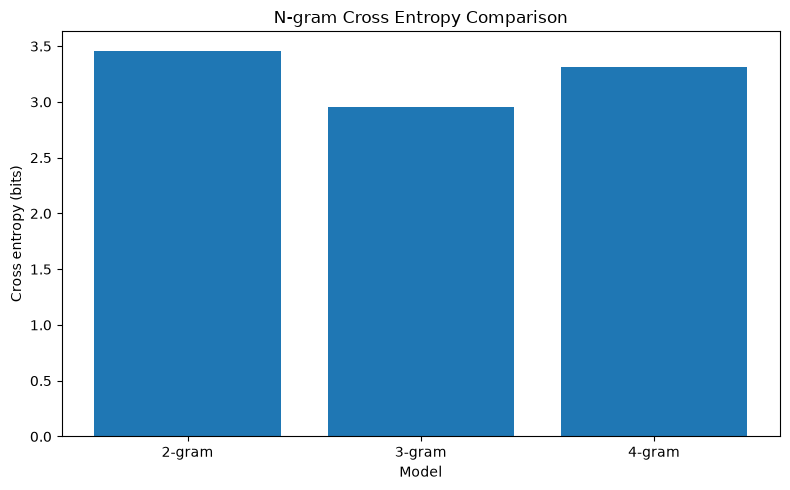

In [10]:
import matplotlib.pyplot as plt

models_names = [
    result["model"]
    for result in results
]

cross_entropy = [
    result["cross_entropy"]
    for result in results
]

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    models_names,
    cross_entropy,
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Cross entropy (bits)"
)

plt.title(
    "N-gram Cross Entropy Comparison"
)

plt.tight_layout()

plt.show()

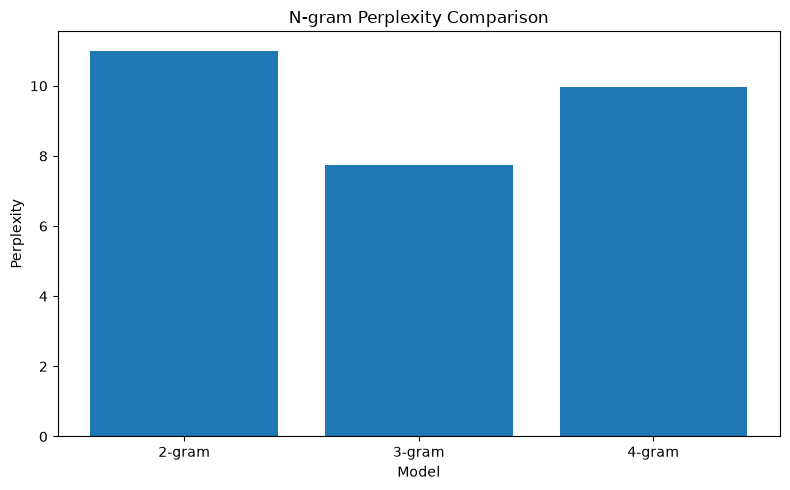

In [11]:
perplexity = [
    result["perplexity"]
    for result in results
]

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    models_names,
    perplexity,
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Perplexity"
)

plt.title(
    "N-gram Perplexity Comparison"
)

plt.tight_layout()

plt.show()